## Objective : 
### Analyse the dataset to identify key factors that influence loan default and provide data-driven insights to support better lending decisions.

In [1]:
import pandas as pd
import matplotlib
credit_risk_1 = pd.read_csv('credit_risk_dataset.csv')

credit_risk_1

,id,Duration in months,Credit history,Purpose of the credit,Credit amount,Status of savings account/bonds,Present employment(years),Installment rate in percentage of disposable income,personal_status,Other debtors / guarantors,...,Property,Age in years,Other installment plans (banks/stores),Housing,Number of existing credits at this bank,Job,Number of people being liable to provide maintenance for,Telephone,Foreign worker,Status of existing checking account
0,1,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,2,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,3,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,4,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,5,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,bad
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,12,existing paid,furniture/equipment,1736,<100,4<=X<7,3,female div/dep/mar,none,...,real estate,31,none,own,1,unskilled resident,1,none,yes,good
996,997,30,existing paid,used car,3857,<100,1<=X<4,4,male div/sep,none,...,life insurance,40,none,own,1,high qualif/self emp/mgmt,1,yes,yes,good
997,998,12,existing paid,radio/tv,804,<100,>=7,4,male single,none,...,car,38,none,own,1,skilled,1,none,yes,good
998,999,45,existing paid,radio/tv,1845,<100,1<=X<4,4,male single,none,...,no known property,23,none,for free,1,skilled,1,yes,yes,bad


## Section 1 : Default Overview
### 1.	What percentage of customers default?
### 2.	Is the dataset balanced between defaulters and non-defaulters?
### 3.	What does this imply about the company’s current risk exposure?


In [4]:
credit_risk_2 = credit_risk_1[[ 'id', 'Credit history', 'Credit amount', 'Number of existing credits at this bank', 'Status of existing checking account']]
credit_risk_2

,id,Credit history,Credit amount,Number of existing credits at this bank,Status of existing checking account
0,1,critical/other existing credit,1169,2,good
1,2,existing paid,5951,1,bad
2,3,critical/other existing credit,2096,1,good
3,4,existing paid,7882,1,good
4,5,delayed previously,4870,2,bad
...,...,...,...,...,...
995,996,existing paid,1736,1,good
996,997,existing paid,3857,1,good
997,998,existing paid,804,1,good
998,999,existing paid,1845,1,bad


### Most likely to default :

In [16]:
defaulters = credit_risk_2[(credit_risk_2['Credit history'] == "critical/other existing credit")&
    (credit_risk_2['Credit amount'] > 5000) & 
    (credit_risk_2['Number of existing credits at this bank'] > 1) & 
    (credit_risk_2['Status of existing checking account'] == "bad")]

defaulters['Default Risk'] = 'high'

defaulters

,id,Credit history,Credit amount,Number of existing credits at this bank,Status of existing checking account,Default Risk
9,10,critical/other existing credit,5234,2,bad,high
44,45,critical/other existing credit,6143,2,bad,high
59,60,critical/other existing credit,6229,2,bad,high
105,106,critical/other existing credit,11938,2,bad,high
113,114,critical/other existing credit,7855,2,bad,high
333,334,critical/other existing credit,11590,2,bad,high
517,518,critical/other existing credit,7127,2,bad,high
701,702,critical/other existing credit,6331,2,bad,high
771,772,critical/other existing credit,8065,2,bad,high
812,813,critical/other existing credit,9629,2,bad,high


### Most likely to NOT default : 

In [14]:
non_defaulters = credit_risk_2[
    (credit_risk_2['Credit history'] == "no credits/all paid") &
    (credit_risk_2['Credit amount'] < 5000) &
    (credit_risk_2['Number of existing credits at this bank'] < 2) & 
    (credit_risk_2['Status of existing checking account'] == "good")
] 

non_defaulters['Default Risk'] = 'low'

non_defaulters

,id,Credit history,Credit amount,Number of existing credits at this bank,Status of existing checking account,Default Risk
26,27,no credits/all paid,426,1,good,low
216,217,no credits/all paid,3104,1,good,low
247,248,no credits/all paid,1204,1,good,low
782,783,no credits/all paid,1410,1,good,low


## Ratio of likely defaulters to non-defaulters

In [17]:
ratio_1 = len(defaulters)
ratio_2 = len(non_defaulters)

print("The ratio of likely defaulters to non-defaulters is " + str(ratio_1) + ":" + str(ratio_2))

The ratio of likely defaulters to non-defaulters is 10:4


## What does this imply about the company’s current risk exposure?

### The company currently faces high financial risk because many clients are unable to repay their credit-based loans. Such a situation leads the company into less profitability. One solution to this problem is to assign higher interest rates to high-risk clients and offer more favorable terms to low-risk clients. This compensates for potential losses and improves overall portfolio balance.

## Section 2: Income & Financial Strength
### 4.	How does income differ between defaulters and non-defaulters?
### 5.	Do lower-income customers show higher default rates?
### 6.	Is there evidence that income level impacts repayment ability?


## Likely Defaulters

In [42]:
defaulters_2 = credit_risk_1[(credit_risk_1['Credit history'] == "critical/other existing credit") &
    (credit_risk_1['Credit amount'] > 5000) & 
    (credit_risk_1['Number of existing credits at this bank'] > 1) & 
    (credit_risk_1['Status of existing checking account'] == "bad")]

defaulters_2[['id', 'Status of savings account/bonds','Installment rate in percentage of disposable income', 'Number of existing credits at this bank','Status of existing checking account']]

,id,Status of savings account/bonds,Installment rate in percentage of disposable income,Number of existing credits at this bank,Status of existing checking account
9,10,<100,4,2,bad
44,45,<100,4,2,bad
59,60,<100,4,2,bad
105,106,<100,2,2,bad
113,114,<100,4,2,bad
333,334,100<=X<500,2,2,bad
517,518,<100,2,2,bad
701,702,<100,4,2,bad
771,772,<100,3,2,bad
812,813,<100,4,2,bad


## Unlikely Defaulters

In [18]:
defaulters_3 = credit_risk_1[
    (credit_risk_1['Credit history'] == "no credits/all paid") & 
    (credit_risk_1['Credit amount'] < 5000) &
    (credit_risk_1['Number of existing credits at this bank'] < 2) & 
    (credit_risk_1['Status of existing checking account'] == "good")
]
defaulters_3[['id', 'Status of savings account/bonds','Installment rate in percentage of disposable income', 'Number of existing credits at this bank','Status of existing checking account']]

,id,Status of savings account/bonds,Installment rate in percentage of disposable income,Number of existing credits at this bank,Status of existing checking account
26,27,<100,4,1,good
216,217,<100,3,1,good
247,248,100<=X<500,4,1,good
782,783,<100,2,1,good


### Income levels are a big part in a client's repayment ability. In this section, the attributes that measure this ability are the status of their savings and checking accounts and the installment rate of their disposable income.
### The difference in income levels between defaulters and non-defaulters is evident, as defaulters are generally low-earning compared to non-defaulters.

# Section 4: Employment Stability
### 10.	Which employment groups have the highest default rates?
### 11.	Does stable employment appear to reduce default risk?

## Likely Defaulters

In [43]:
employment_1 = credit_risk_1[(credit_risk_1['Credit history'] == "critical/other existing credit") &
    (credit_risk_1['Credit amount'] > 5000) & 
    (credit_risk_1['Number of existing credits at this bank'] > 1) & 
    (credit_risk_1['Status of existing checking account'] == "bad")]

employment_1[['id','Job','Present employment(years)', 'Age in years']]

,id,Job,Present employment(years),Age in years
9,10,high qualif/self emp/mgmt,unemployed,28
44,45,unskilled resident,>=7,58
59,60,unskilled resident,<1,23
105,106,high qualif/self emp/mgmt,1<=X<4,39
113,114,skilled,1<=X<4,25
333,334,unskilled resident,1<=X<4,24
517,518,skilled,<1,23
701,702,skilled,>=7,46
771,772,high qualif/self emp/mgmt,1<=X<4,25
812,813,skilled,4<=X<7,24


<Axes: xlabel='Job'>

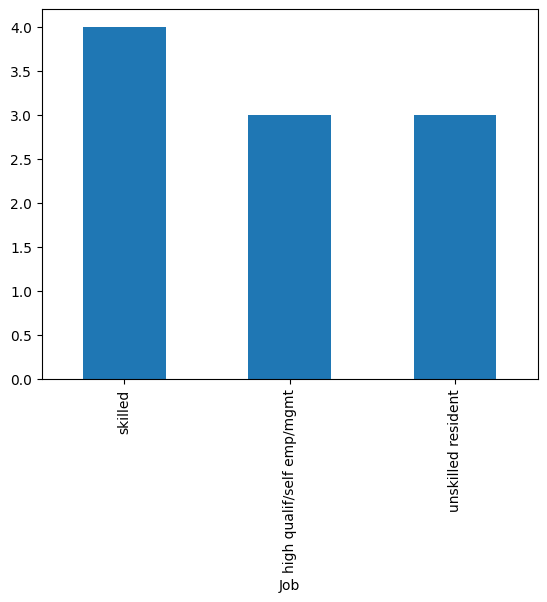

In [44]:
employment_1['Job'].value_counts().plot(kind='bar')

<Axes: xlabel='Present employment(years)'>

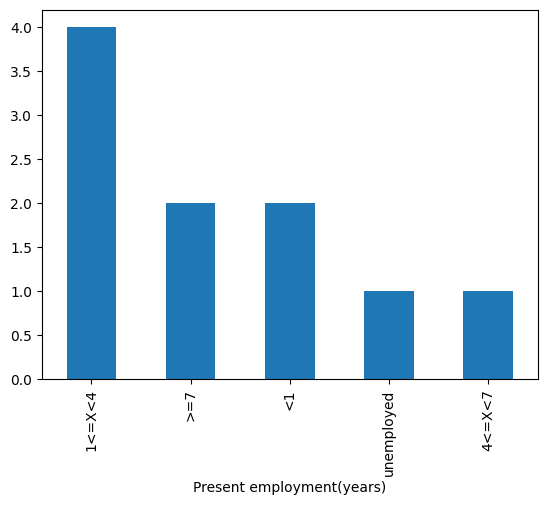

In [45]:
employment_1['Present employment(years)'].value_counts().plot(kind='bar')

## Unlikely Defaulters

In [19]:
employment_2 = credit_risk_1[
    (credit_risk_1['Credit history'] == "no credits/all paid") & 
    (credit_risk_1['Credit amount'] < 5000) &
    (credit_risk_1['Number of existing credits at this bank'] < 2) & 
    (credit_risk_1['Status of existing checking account'] == "good")
]

employment_2[['id','Job','Present employment(years)', 'Age in years']]

,id,Job,Present employment(years),Age in years
26,27,unskilled resident,>=7,39
216,217,skilled,4<=X<7,31
247,248,skilled,1<=X<4,35
782,783,unskilled resident,1<=X<4,31


<Axes: xlabel='Job'>

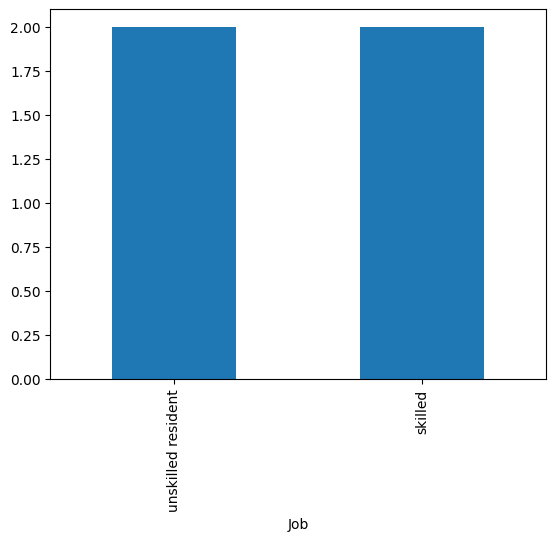

In [33]:
employment_2['Job'].value_counts().plot(kind='bar')

<Axes: xlabel='Present employment(years)'>

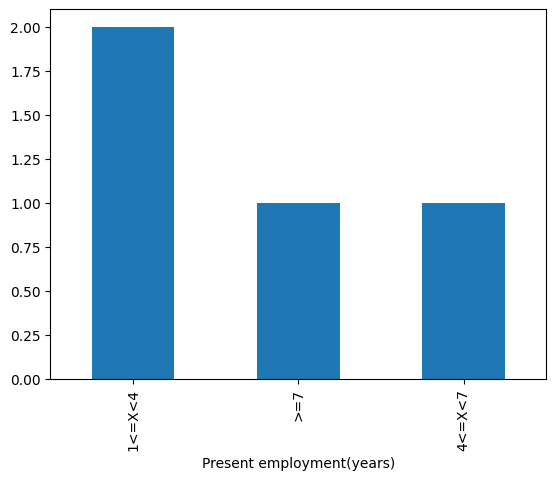

In [38]:
employment_2['Present employment(years)'].value_counts().plot(kind='bar')

# Final Deliverable

### The biggest factor contributing to a client's default risk and repayment ability (low / high) is their income and financial strength, measured in this analysis by the status of their savings and checking accounts and the installment rate of their disposable income.
### Even though a client's employment stability contributes to their default risk and repayment ability, other external factors such as cost of living, healthcare, inflation, and taxes must also be taken into consideration.